# Customer Intelligence System

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Loading Dataset

In [4]:
df = pd.read_csv('/content/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
median_gdp = df['gdpp'].median()
df['target'] = (df['gdpp'] > median_gdp).astype(int)

X = df.drop(['country','gdpp','target'], axis=1)
y = df['target']

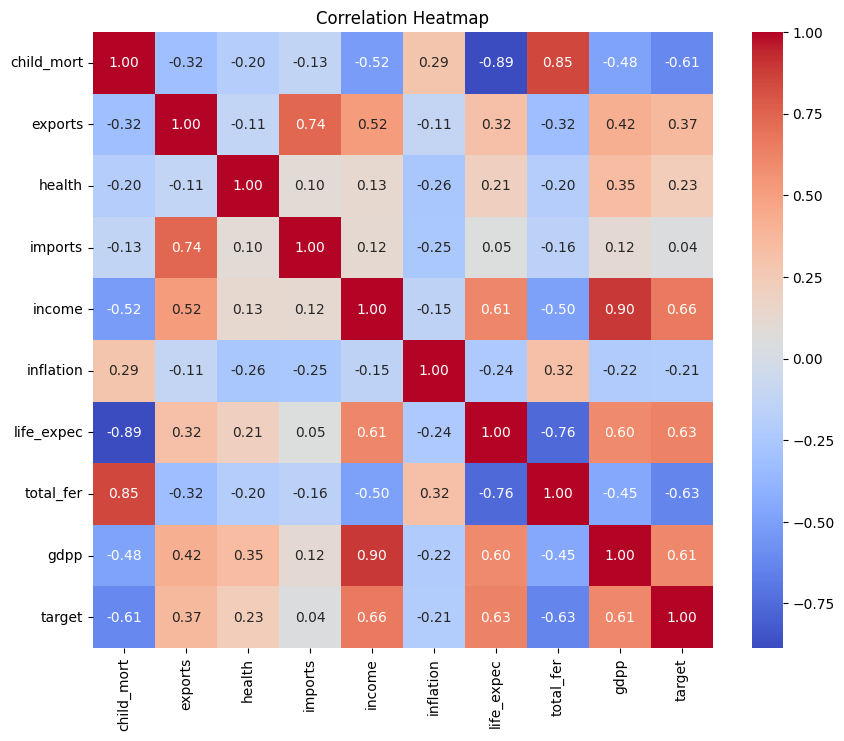

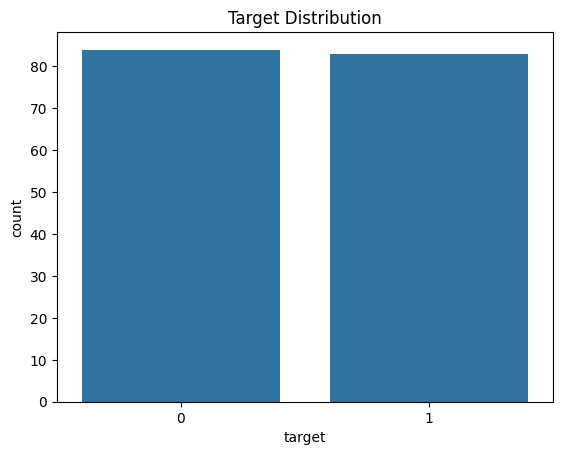

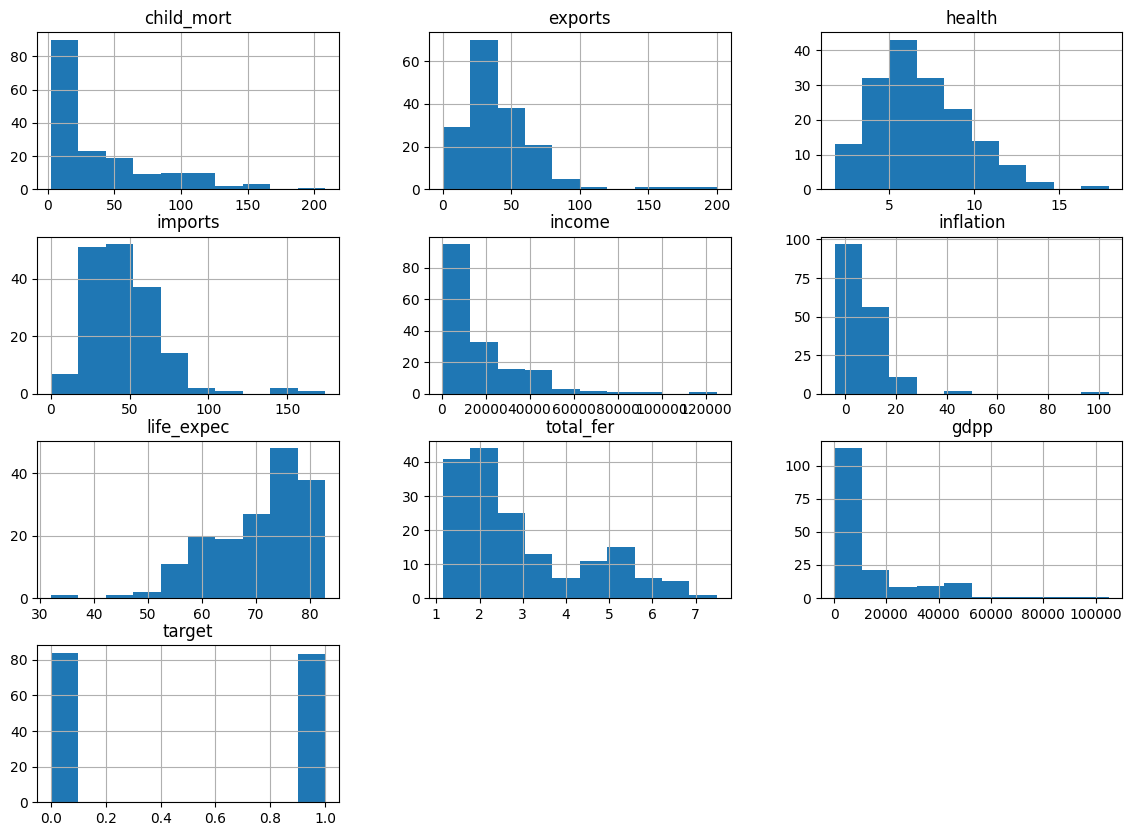

In [7]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

sns.countplot(x=y)
plt.title('Target Distribution')
plt.show()

df.hist(figsize=(14,10))
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    [('num', StandardScaler(), X.columns)]
)

## Random Forest

In [9]:
rf_pipeline = Pipeline([
('preprocess',preprocessor),
('model',RandomForestClassifier(random_state=42))
])

params={
'model__n_estimators':[100,200],
'model__max_depth':[4,6,8]
}

rf_grid=GridSearchCV(rf_pipeline,params,cv=5,n_jobs=-1)
rf_grid.fit(X_train,y_train)

pred_rf=rf_grid.predict(X_test)
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.89      0.94      0.91        17

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.91      0.91      0.91        34



## XGBoost

In [10]:
xgb_model = Pipeline([
('preprocess',preprocessor),
('model',XGBClassifier(
learning_rate=0.05,
max_depth=4,
n_estimators=150,
subsample=0.8,
colsample_bytree=0.8,
eval_metric='logloss'))
])

xgb_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               ear...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=None,
                               num_parallel_tree=None, ...))])

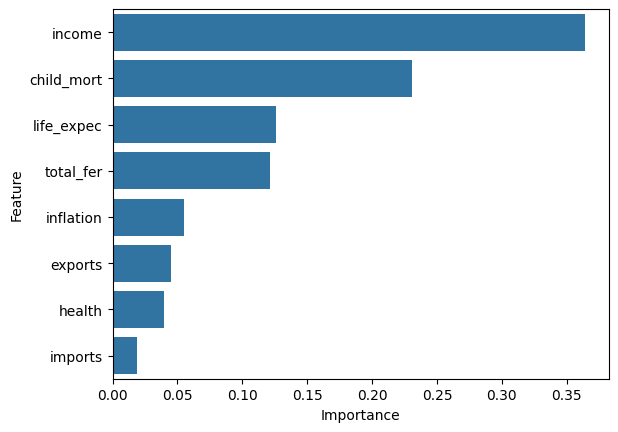

In [11]:
best_rf = rf_grid.best_estimator_.named_steps['model']

importance = pd.DataFrame({
'Feature':X.columns,
'Importance':best_rf.feature_importances_
}).sort_values(by='Importance',ascending=False)

sns.barplot(data=importance,x='Importance',y='Feature')
plt.show()

## KMeans and DBSCAN

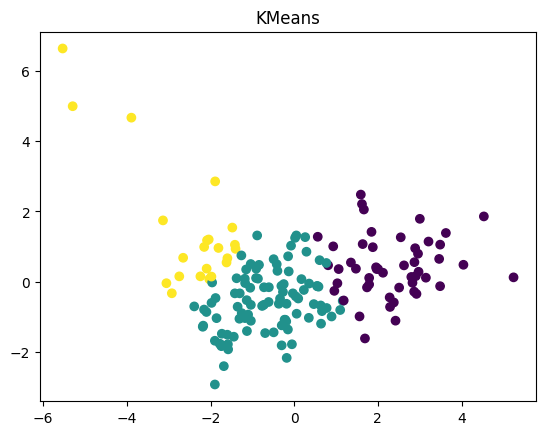

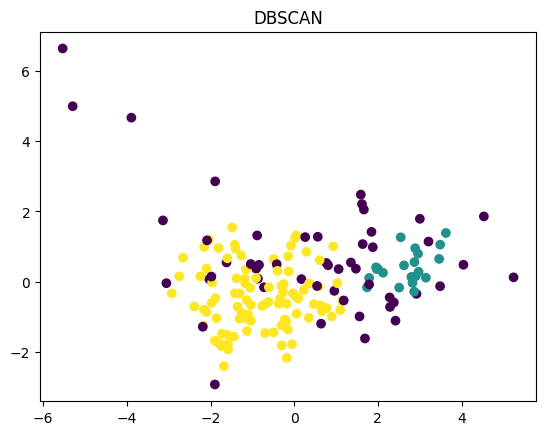

In [13]:
scaled_data = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

dbscan = DBSCAN(eps=1.2, min_samples=5)
db_clusters = dbscan.fit_predict(scaled_data)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
plt.title('KMeans')
plt.show()

plt.scatter(pca_data[:,0], pca_data[:,1], c=db_clusters)
plt.title('DBSCAN')
plt.show()